# All Symbols Correlation Analysis

This notebook fetches all active symbols from the Binbot API, retrieves candlestick data from Binance for each symbol, and computes a correlation matrix among all assets. The correlation matrix is visualized as a heatmap for easy analysis.

In [13]:
%pip install -q ipywidgets seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
# Import Required Libraries
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

## Fetch All Active Symbols from API

We will use the Binbot API to get all active trading symbols.

In [ ]:
# Fetch all active symbols from the API
base_url = "https://api.terminal.binbot.in"
symbols_url = f"{base_url}/symbols"
symbols_resp = requests.get(symbols_url)
symbols_data = symbols_resp.json()["data"]
active_symbols = [s["id"] for s in symbols_data if s.get("active")]
print(f"Found {len(active_symbols)} active symbols.")
# Optionally, preview a few symbols
print("Sample symbols:", active_symbols[:10])

Found 480 active symbols.
Sample symbols: ['ETHBTC', 'QTUMBTC', 'ETCETH', 'POWRBTC', 'MANAETH', 'RLCBTC', 'ZENBTC', 'VETBTC', 'LTCUSDC', 'PHBBTC']


## Fetch Candlestick Data for Each Symbol

We will fetch recent 15m candlestick close prices for each active symbol from Binance.

In [ ]:
# Fetch candlestick close prices for each symbol from Binance
from tqdm.notebook import tqdm
import time

def fetch_binance_closes(symbol, interval="15m", limit=200):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    resp = requests.get(url, params=params)
    if resp.status_code != 200:
        return None
    data = resp.json()
    if not data:
        return None
    df = pd.DataFrame(data, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "qav", "num_trades", "taker_base", "taker_quote", "ignore"
    ])
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    df["close"] = df["close"].astype(float)
    return df[["timestamp", "close"]]

closes_dict = {}
for symbol in tqdm(active_symbols, desc="Fetching candlesticks"):
    try:
        df = fetch_binance_closes(symbol)
        if df is not None and len(df) > 0:
            closes_dict[symbol] = df.set_index("timestamp")["close"]
        time.sleep(0.1)  # Be nice to the API
    except Exception as e:
        print(f"Failed for {symbol}: {e}")

print(f"Fetched data for {len(closes_dict)} symbols.")

Fetching candlesticks:   0%|          | 0/480 [00:00<?, ?it/s]

## Combine Closing Prices into a Single DataFrame

We will align all symbols' close prices by timestamp and combine them into a single DataFrame.

In [ ]:
# Combine all close price series into a single DataFrame
if closes_dict:
    df_closes = pd.DataFrame(closes_dict)
    print(f"Combined DataFrame shape: {df_closes.shape}")
    display(df_closes.tail())
else:
    print("No close price data available.")

Combined DataFrame shape: (200, 480)


,ETHBTC,QTUMBTC,ETCETH,POWRBTC,MANAETH,RLCBTC,ZENBTC,VETBTC,LTCUSDC,PHBBTC,...,LDOUSDC,1000SATSUSDC,SLFUSDC,PNUTBTC,EIGENUSDC,SANDUSDC,ORCAUSDC,PHAUSDC,TRUMPUSDC,CAKEUSDC
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-09-01 21:15:00,0.03953,0.000024,0.00475,0.000001,0.000066,0.000011,0.000063,2.200000e-07,107.63,0.000005,...,1.1459,0.000033,0.0528,0.000002,1.122,0.2649,2.131,0.1006,8.25,2.369
2025-09-01 21:30:00,0.03942,0.000024,0.00476,0.000001,0.000066,0.000011,0.000063,2.200000e-07,106.85,0.000005,...,1.1376,0.000033,0.0518,0.000002,1.110,0.2635,2.119,0.0997,8.26,2.355
2025-09-01 21:45:00,0.03953,0.000024,0.00476,0.000001,0.000066,0.000011,0.000063,2.200000e-07,107.13,0.000005,...,1.1432,0.000033,0.0517,0.000002,1.117,0.2649,2.136,0.1003,8.26,2.371
2025-09-01 22:00:00,0.03962,0.000024,0.00473,0.000001,0.000066,0.000011,0.000063,2.200000e-07,107.09,0.000005,...,1.1460,0.000033,0.0519,0.000002,1.121,0.2644,2.136,0.1000,8.28,2.371
2025-09-01 22:15:00,0.03972,0.000024,0.00473,0.000001,0.000066,0.000011,0.000063,2.200000e-07,107.55,0.000005,...,1.1470,0.000033,0.0514,0.000002,1.122,0.2648,2.138,0.1002,8.27,2.366


## Compute Correlation Matrix

We will calculate the correlation matrix for the closing prices of all symbols.

In [ ]:
# Compute the correlation matrix for the closing prices
if 'df_closes' in locals() and not df_closes.empty:
    corr_matrix = df_closes.corr()
    print(f"Correlation matrix shape: {corr_matrix.shape}")
    display(corr_matrix)
else:
    print("No closing price data to compute correlation matrix.")

Correlation matrix shape: (480, 480)


,ETHBTC,QTUMBTC,ETCETH,POWRBTC,MANAETH,RLCBTC,ZENBTC,VETBTC,LTCUSDC,PHBBTC,...,LDOUSDC,1000SATSUSDC,SLFUSDC,PNUTBTC,EIGENUSDC,SANDUSDC,ORCAUSDC,PHAUSDC,TRUMPUSDC,CAKEUSDC
ETHBTC,1.000000,0.367557,-0.421135,0.769896,-0.234506,0.460587,0.746741,0.487138,0.527903,0.703463,...,0.663236,0.658907,0.597281,0.702100,0.737601,0.803488,0.588314,0.772726,0.299454,0.741606
QTUMBTC,0.367557,1.000000,0.459975,0.788040,0.074807,0.026975,0.762190,0.518133,0.542113,0.797546,...,0.636735,0.813804,0.718355,0.833578,0.725729,0.536055,0.771224,0.731962,-0.294772,0.732989
ETCETH,-0.421135,0.459975,1.000000,0.173549,0.492979,-0.090466,0.177783,0.020084,0.378905,0.241900,...,0.265034,0.312937,0.021799,0.259839,0.213648,0.021077,0.379570,0.136728,-0.245755,0.219288
POWRBTC,0.769896,0.788040,0.173549,1.000000,0.087794,0.382589,0.946382,0.572910,0.785561,0.953138,...,0.898476,0.932986,0.746609,0.953707,0.943249,0.877815,0.915581,0.945480,0.001866,0.922114
MANAETH,-0.234506,0.074807,0.492979,0.087794,1.000000,0.091466,0.066423,-0.201847,0.417528,0.119029,...,0.252165,0.138102,-0.135250,0.044186,0.118750,0.246496,0.243663,0.014880,-0.339713,0.039061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SANDUSDC,0.803488,0.536055,0.021077,0.877815,0.246496,0.504573,0.866588,0.507903,0.831439,0.869759,...,0.901337,0.861825,0.630766,0.843847,0.921686,1.000000,0.859345,0.893588,0.148918,0.869722
ORCAUSDC,0.588314,0.771224,0.379570,0.915581,0.243663,0.367410,0.937898,0.558710,0.888636,0.952807,...,0.958580,0.964806,0.657212,0.942828,0.961015,0.859345,1.000000,0.939062,-0.042613,0.911664
PHAUSDC,0.772726,0.731962,0.136728,0.945480,0.014880,0.419122,0.962257,0.621606,0.791060,0.952265,...,0.924587,0.950254,0.756942,0.956486,0.970093,0.893588,0.939062,1.000000,0.120316,0.935470
TRUMPUSDC,0.299454,-0.294772,-0.245755,0.001866,-0.339713,0.206243,-0.008897,-0.053294,0.063974,0.000164,...,0.021202,0.047576,0.110772,0.047823,0.122085,0.148918,-0.042613,0.120316,1.000000,0.223155


## Visualize Correlation Matrix

We will plot a heatmap of the correlation matrix for visual analysis.

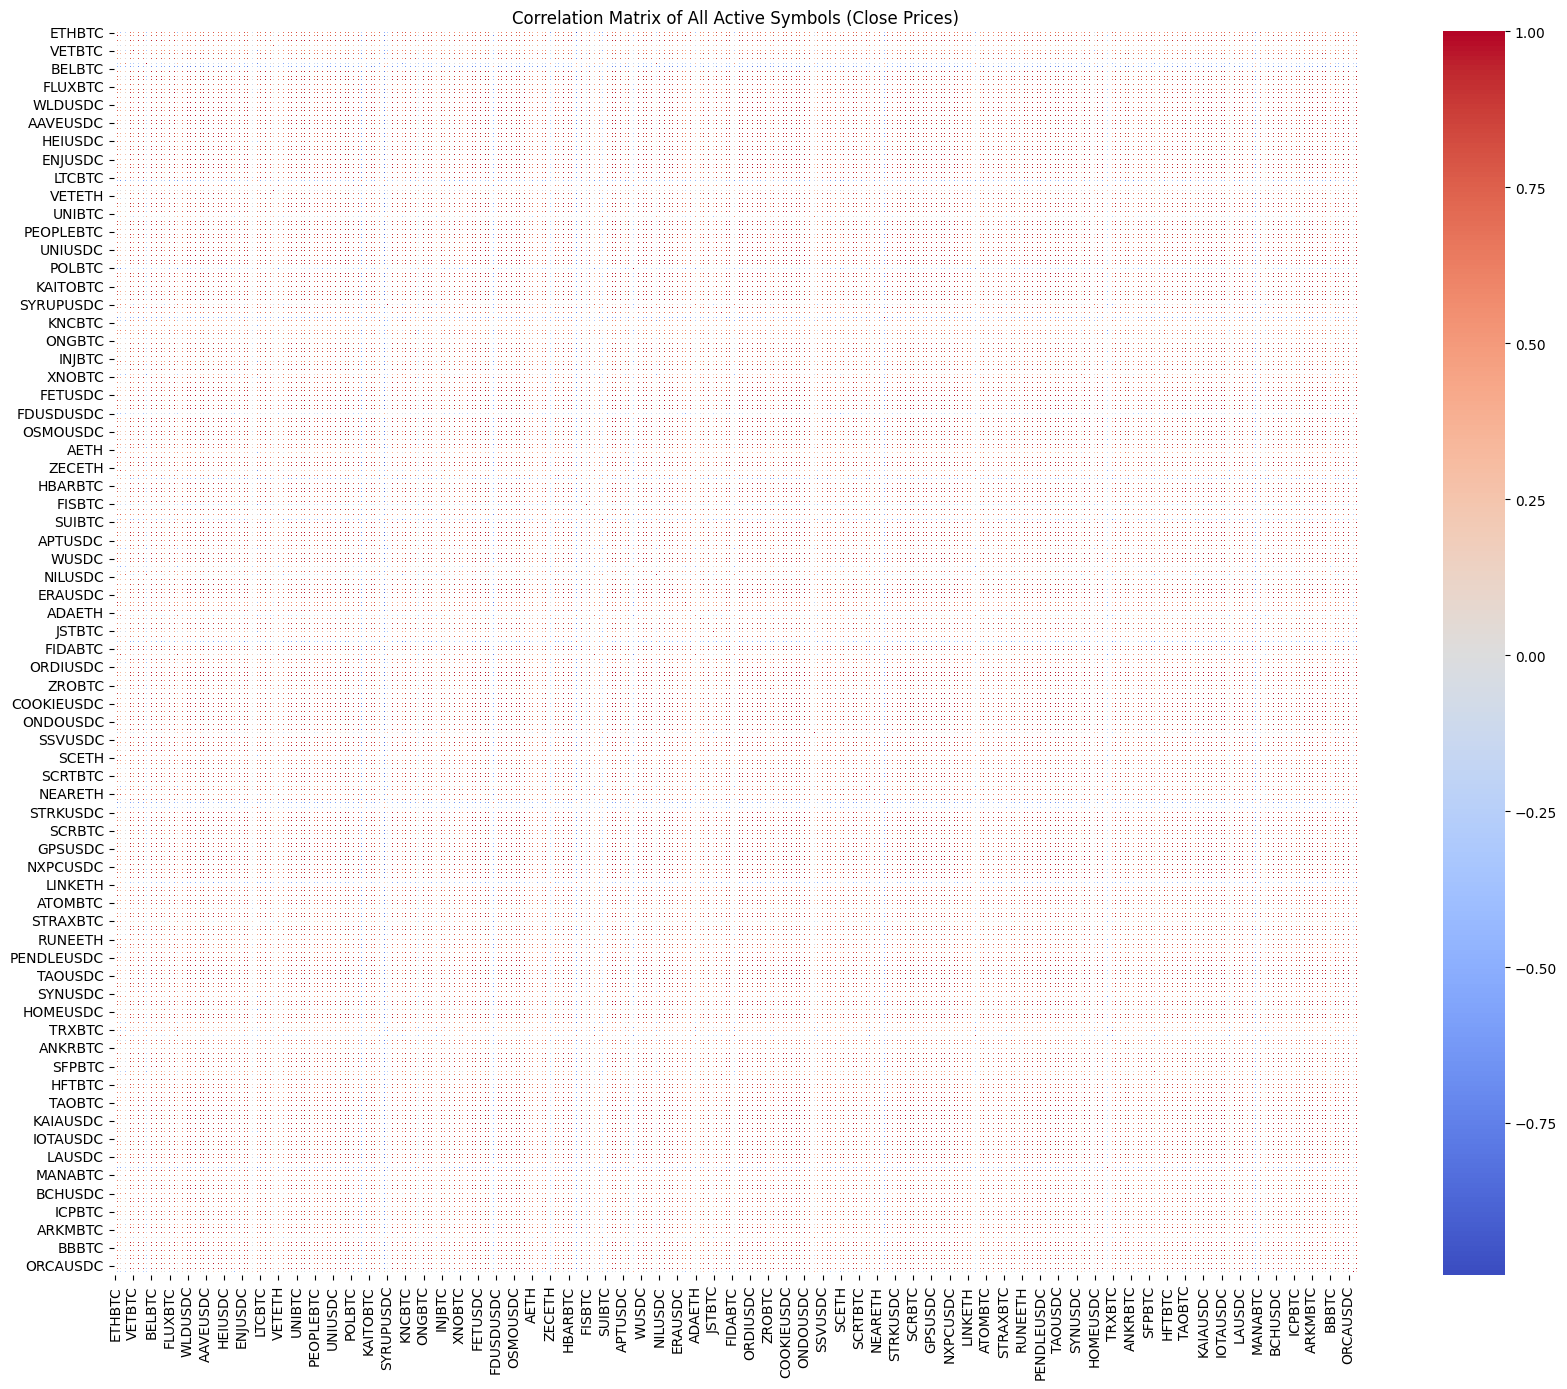

In [ ]:
# Plot a heatmap of the correlation matrix
if 'corr_matrix' in locals() and not corr_matrix.empty:
    plt.figure(figsize=(18, 14))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, linewidths=0.1)
    plt.title('Correlation Matrix of All Active Symbols (Close Prices)')
    plt.tight_layout()
    plt.show()
else:
    print("No correlation matrix to plot.")

## Group Assets by Correlation Sign and Visualize

Instead of a heatmap, we will group asset pairs by positive and negative correlations and visualize them in a scatterplot. Each point will represent a pair of assets, with the x-axis as one asset, y-axis as the other, and color indicating positive or negative correlation.

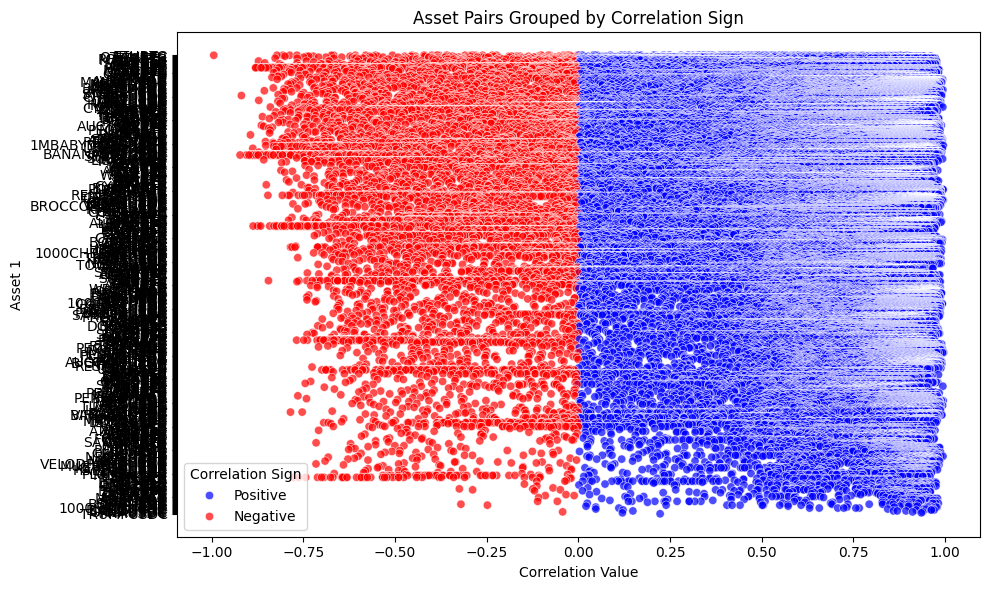

In [ ]:
# Group asset pairs by correlation sign and plot as scatterplot
if 'corr_matrix' in locals() and not corr_matrix.empty:
    corr_pairs = corr_matrix.stack().reset_index()
    corr_pairs.columns = ['Asset1', 'Asset2', 'Correlation']
    # Remove self-correlations
    corr_pairs = corr_pairs[corr_pairs['Asset1'] != corr_pairs['Asset2']]
    # Drop duplicate pairs (A,B) and (B,A)
    corr_pairs['pair'] = corr_pairs.apply(lambda x: tuple(sorted([x['Asset1'], x['Asset2']])), axis=1)
    corr_pairs = corr_pairs.drop_duplicates('pair')
    # Group by sign
    corr_pairs['Sign'] = np.where(corr_pairs['Correlation'] < 0, 'Negative', 'Positive')
    # Scatterplot: x=Correlation, y=Asset1, color=Sign
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=corr_pairs,
        x='Correlation',
        y='Asset1',
        hue='Sign',
        palette={'Positive': 'blue', 'Negative': 'red'},
        alpha=0.7
    )
    plt.title('Asset Pairs Grouped by Correlation Sign')
    plt.xlabel('Correlation Value')
    plt.ylabel('Asset 1')
    plt.legend(title='Correlation Sign')
    plt.tight_layout()
    plt.show()
else:
    print("No correlation matrix to plot.")

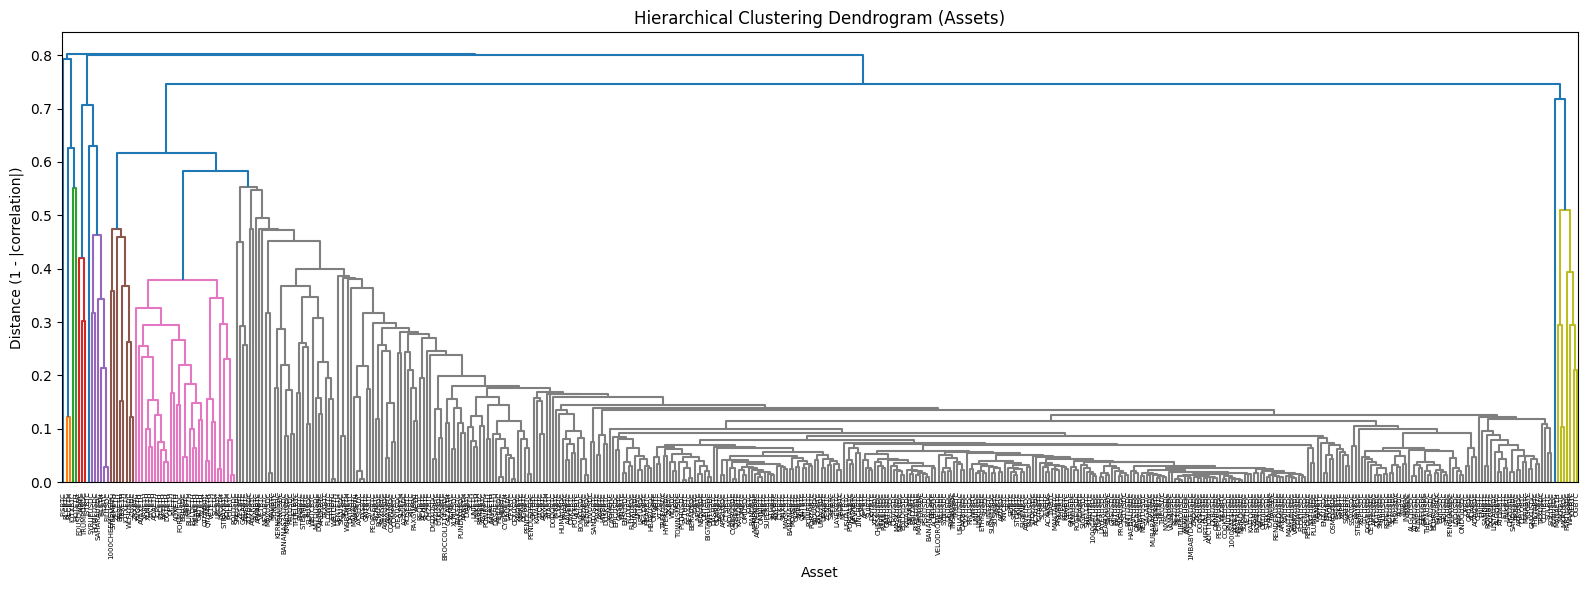

Cluster assignments (asset: cluster):
{'ETHBTC': np.int32(4), 'QTUMBTC': np.int32(4), 'ETCETH': np.int32(4), 'POWRBTC': np.int32(4), 'MANAETH': np.int32(5), 'RLCBTC': np.int32(1), 'ZENBTC': np.int32(4), 'VETBTC': np.int32(4), 'LTCUSDC': np.int32(4), 'PHBBTC': np.int32(4), 'CHZBTC': np.int32(4), 'OGNBTC': np.int32(4), 'MKRBTC': np.int32(5), 'PAXGBTC': np.int32(4), 'BELBTC': np.int32(4), 'NEARBTC': np.int32(4), 'GLMBTC': np.int32(4), 'CAKEBTC': np.int32(4), 'ARBTC': np.int32(4), 'GALABTC': np.int32(4), 'SSVETH': np.int32(4), 'FLUXBTC': np.int32(4), 'UNIETH': np.int32(4), 'LDOBTC': np.int32(4), 'APTETH': np.int32(4), 'WLDBTC': np.int32(4), 'AVAXUSDC': np.int32(4), 'MANTAUSDC': np.int32(4), 'WLDUSDC': np.int32(4), 'NEARUSDC': np.int32(4), 'JTOUSDC': np.int32(4), 'RUNEUSDC': np.int32(4), 'TRBUSDC': np.int32(4), 'NOTUSDC': np.int32(4), 'BANANABTC': np.int32(4), 'AAVEUSDC': np.int32(4), 'PNUTUSDC': np.int32(4), 'MEMEUSDC': np.int32(4), 'CHZUSDC': np.int32(4), 'HIVEUSDC': np.int32(4), 'STEEMUS

In [ ]:
# Hierarchical clustering of assets based on correlation
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

if 'corr_matrix' in locals() and not corr_matrix.empty:
    # Fill NaN in correlation matrix with 0 (treat as no correlation)
    corr_filled = corr_matrix.fillna(0)
    # Convert correlation to distance
    distance_matrix = 1 - corr_filled.abs()
    # Set diagonal to 0 (distance to self)
    np.fill_diagonal(distance_matrix.values, 0)
    # Check if the matrix is square and non-empty
    if not distance_matrix.empty and distance_matrix.shape[0] == distance_matrix.shape[1]:
        # Convert to condensed distance matrix for linkage
        condensed_dist = squareform(distance_matrix.values, checks=False)
        # Perform hierarchical clustering
        Z = linkage(condensed_dist, method='average')
        # Plot dendrogram
        plt.figure(figsize=(16, 6))
        dendrogram(Z, labels=distance_matrix.columns, leaf_rotation=90)
        plt.title('Hierarchical Clustering Dendrogram (Assets)')
        plt.xlabel('Asset')
        plt.ylabel('Distance (1 - |correlation|)')
        plt.tight_layout()
        plt.show()
        # Optionally, assign cluster labels (e.g., 5 clusters)
        cluster_labels = fcluster(Z, t=5, criterion='maxclust')
        asset_clusters = dict(zip(distance_matrix.columns, cluster_labels))
        print('Cluster assignments (asset: cluster):')
        print(asset_clusters)
    else:
        print('No sufficient data for clustering (distance matrix is empty or not square).')
else:
    print('No correlation matrix to cluster.')

In [ ]:
# Assign clusters using a distance threshold of 0.4 and print the results
from scipy.cluster.hierarchy import fcluster
from collections import defaultdict

if 'Z' in locals():
    cluster_labels_04 = fcluster(Z, t=0.30, criterion='distance')
    asset_clusters_04 = dict(zip(distance_matrix.columns, cluster_labels_04))
    unique_clusters_04 = set(cluster_labels_04)
    print(f"Number of clusters at distance threshold 0.4: {len(unique_clusters_04)}")
    print(f"Cluster labels: {sorted(unique_clusters_04)}")
    # Optionally, show a few assets per cluster
    clusters_dict = defaultdict(list)
    for symbol, label in asset_clusters_04.items():
        clusters_dict[label].append(symbol)
    for label, symbols in clusters_dict.items():
        print(f"Cluster {label}: {symbols[:5]}{'...' if len(symbols) > 5 else ''}")
else:
    print('No linkage matrix Z found. Run the clustering cell first.')

Number of clusters at distance threshold 0.4: 44
Cluster labels: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31), np.int32(32), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), np.int32(39), np.int32(40), np.int32(41), np.int32(42), np.int32(43), np.int32(44)]
Cluster 30: ['ETHBTC', 'WBTCETH', 'FLOWBTC', 'DOLOUSDC', 'TRXBTC']...
Cluster 20: ['QTUMBTC', 'VETETH', 'QTUMETH', 'SCETH']
Cluster 18: ['ETCETH', 'APTETH', 'ADXETH', 'GRTETH', 'OPETH']...
Cluster 34: ['POWRBTC', 'ZENBTC', 'LTCUSDC', 'PHBBTC', 'CHZBTC']...
Cluster 41: ['MANAETH', 'MKRBTC', 'MKRUSDC']
Cluster 1: ['RLCBTC', 'RL

In [ ]:
# KMeans clustering on PCA-reduced correlation data
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np
from collections import defaultdict, Counter

# Use the absolute correlation matrix as features
if 'corr_matrix' in locals() and not corr_matrix.empty:
    corr_features = corr_matrix.abs().fillna(0)
    # Optionally, reduce dimensionality for clustering
    pca = PCA(n_components=min(10, corr_features.shape[1]))
    features_pca = pca.fit_transform(corr_features)
    # Choose number of clusters (e.g., 5, or use elbow method)
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(features_pca)
    asset_kmeans_clusters = dict(zip(corr_features.index, kmeans_labels))
    clusters_dict = defaultdict(list)
    for symbol, label in asset_kmeans_clusters.items():
        clusters_dict[label].append(symbol)
    print(f'Number of clusters: {len(clusters_dict)}')
    # Collect a Counter for each cluster, counting each asset_index name only once per symbol
    cluster_counters = {}
    symbols_resp = requests.get(f"{base_url}/symbols?symbol={symbol}")
    symbols_data = symbols_resp.json()["data"]
    for label, symbols in sorted(clusters_dict.items()):
        asset_index_counter = Counter()
        for symbol in symbols:
            try:
                unique_names = set()
                for asset in symbols_data:
                    if asset["id"] == symbol:
                        for indx in asset.get("asset_indices", []):
                            asset_index_counter[indx["name"]] += 1
                        continue
                            
                
            except Exception as e:
                print(f'Error fetching for symbol {symbol}: {e}')
            cluster_counters[label] = asset_index_counter

    for key, value in cluster_counters.items():
        print(f'Cluster {key}: {value}')

else:
    print('No correlation matrix available for KMeans clustering.')

Number of clusters: 5
Cluster 0: Counter()
Cluster 1: Counter()
Cluster 2: Counter()
Cluster 3: Counter()
Cluster 4: Counter()


In [ ]:
# Assign asset index to each symbol in each cluster via PUT request
import requests

cluster_0_index = "meme"
cluster_1_index = "launchpool"
cluster_2_index = "infrastructure"
cluster_3_index = "hodler"
cluster_4_index = "layers"

# Define the mapping from cluster number to cluster index variable
cluster_indices = {
    0: cluster_0_index,
    1: cluster_1_index,
    2: cluster_2_index,
    3: cluster_3_index,
    4: cluster_4_index,
}

for cluster_num, symbols in clusters_dict.items():
    cluster_index = cluster_indices[cluster_num]
    for symbol in symbols:
        payload = {
            "id": symbol,
            "asset_indices": [
                {"id": cluster_index, "name": cluster_index.capitalize()}
            ],
        }
        
        try:
            response = requests.put(
                f"{base_url}/symbol/asset-index", json=payload
            )
            print(
                f"PUT {symbol} to cluster {cluster_num} ({cluster_index}): {response.status_code}"
            )
        except Exception as e:
            print(f"Error for symbol {symbol}: {e}")


PUT ETHBTC to cluster 3 (hodler): 200
PUT VETBTC to cluster 3 (hodler): 200
PUT GALABTC to cluster 3 (hodler): 200
PUT TUTUSDC to cluster 3 (hodler): 200
PUT WLFIUSDC to cluster 3 (hodler): 200
PUT TFUELBTC to cluster 3 (hodler): 200
PUT BANANAS31USDC to cluster 3 (hodler): 200
PUT AXSUSDC to cluster 3 (hodler): 200
PUT BNBBTC to cluster 3 (hodler): 200
PUT ZECBTC to cluster 3 (hodler): 200
PUT RVNBTC to cluster 3 (hodler): 200
PUT WBTCBTC to cluster 3 (hodler): 200
PUT KMNOUSDC to cluster 3 (hodler): 200
PUT IOTXETH to cluster 3 (hodler): 200
PUT WBTCETH to cluster 3 (hodler): 200
PUT DATABTC to cluster 3 (hodler): 200
PUT AXSBTC to cluster 3 (hodler): 200
PUT OGBTC to cluster 3 (hodler): 200
PUT WBETHETH to cluster 3 (hodler): 200
PUT TONUSDC to cluster 3 (hodler): 200
PUT CUSDC to cluster 3 (hodler): 200
PUT FLOWBTC to cluster 3 (hodler): 200
PUT BNBETH to cluster 3 (hodler): 200
PUT DENTETH to cluster 3 (hodler): 200
PUT RIFBTC to cluster 3 (hodler): 200
PUT AWEBTC to cluster 3 (ho